<a href="https://colab.research.google.com/github/saai07/Hazelnut_defects_detection/blob/main/Copy_of_Akridata_ML_Intern_Sep25_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

This notebook contains the coding assignment for Akridata's ML internships (September 2025).

  * [Job description](https://docs.google.com/document/d/e/2PACX-1vRwHkY0TLebdoe-meFsgM3p3DdReJq5Kl1fVN5-tHZrYEuXwo7vYvbIkxa2oQNH4D26Hsv9wP7Mup1l/pub)
  * [Application form](https://docs.google.com/forms/d/e/1FAIpQLSdTW9OQXXlHkjKCcxgil4H3BgwPvOrlnqzL0JsqBh5xyAK0aQ/viewform?usp=dialog)

## Why This Assignment Exists

We receive far more applications than we can meaningfully review — it's too easy to click “Apply” online. That flood inevitably includes many who aren't a fit for the role. We don't want to filter by college names or grades alone.

So we add **a bit of friction**: a real, hands-on task. Yes, it's extra work — but it's a better signal than a resume or a keyword-stuffed LinkedIn profile.

We've picked something that:
- Is technically straightforward to complete in a reasonable time.
- Is interesting and directly relevant to the problems we solve.
- Gives you a taste of how we actually work.

You are free to use any tools (Google, Forums, Cursor, GenAI) you want to complete this assignment - as long as you do it yourself. You must understand what you do though. We may quiz you on this if you get shortlisted.

## Publishing Your Code

Once the interview process wraps up, we encourage you to publish your solution and add it to your portfolio. Until then, please keep it private so everyone gets a fair shot.

## The Task: Defect Classification

At Akridata, we focus on the **critical edge cases of manufacturing inspection** — where failures are costly, dangerous, or both.  
Think precision lenses and glass components that could shatter, ball bearings that can fail in high-stress machinery, or kilometers of railway track that no human can realistically inspect end-to-end. We also handle inspection problems where rules-based computer vision falls short — like detecting subtle miswirings in cable assemblies, spotting PCB defects in complex layouts, or checking extremely small parts where manual inspection is painfully slow.

This task gives you a glimpse into vision-based inspection work.  
You'll tackle **zero-shot defect classification** for a real-world-like case: detecting surface defects in hazelnut images from the MVTec-AD dataset, using OpenAI's `CLIP` vision-language model.


# IMPORTANT

## Before proceeding, copy this notebook into your Google Drive, and make changes to your local copy.

You have to share the link to your local copy.

# Zero-Shot Defect Classification with CLIP (Git + Colab Workflow)

## Overview

In this assignment, you will:
- Use OpenAI's CLIP model to perform zero-shot defect classification on the `hazelnut` subset of the MVTec-AD dataset (test split).
- Implement a configuration class (Pydantic) and a classification function in Python.
- Practice basic Git workflows: branching, committing, merging, and preserving commit history.
- Run your completed code on real image data and produce a confusion matrix.

All work must be done entirely inside this Colab notebook, including:
- Running Git commands
- Editing files in the cloned repository
- Installing and importing packages

We will run the code in this notebook to verify the submission.

*The cells marked as 'TO DO' are the ones where you have to edit code (or text).*


---

## Task Sequence


* **Data Setup**
   - Download and extract the MVTec-AD dataset.
   - Verify that `hazelnut` images are present in the test split.

* **Repository Setup**
   - Clone the provided repository into your Colab environment.
   - Switch to the `feature` branch for development.
   - Place the hazelnut images from the test split inside the `data/` directory of the cloned repository.

* **Implementation**
   - Complete the `DefectClassificationSpec` class in `spec.py`.
   - Complete the `classify_defects()` function in `classification.py`.

* **Execution**
   - Run your classification function on the downloaded test dataset.
   - Generate and display a confusion matrix comparing predictions with ground truth.

* **Git Workflow**
   - Commit your changes to the `feature` branch.
   - Merge the `feature` branch into the `main` branch.
   - Switch to `main` to prepare for execution.

* **Submission**
   - Leave all code cells and outputs visible in this notebook.
   - Generate a link to the notebook using the `Share` button in the top-right of the Colab page.
   - Verify that you can see the contents of the notebook from a different browser where you are not signed in to your account.
   - Share the link to the notebook in our application form.

## References
- [CLIP](https://github.com/openai/CLIP)
- [MVTec-AD](https://www.mvtec.com/company/research/datasets/mvtec-ad)
- [Pydantic](https://docs.pydantic.dev/latest/)
- [CLIP-AC (WinCLIP)](https://arxiv.org/abs/2303.14814)
  - See section 4.1 in the WinCLIP paper for a
    basic two-class design for anomaly classification.
  - Extend this to a defect classification problem for multiple defect classes for this task.

# Download and extract dataset

In [1]:
#@title Download a the dataset sample from Supervisely
!curl https://assets.supervisely.com/supervisely-supervisely-assets-public/teams_storage/W/6/pt/ANAGVgKaC62tTrDQWK5JhNP2dd8ynqaTKSM1QdVoAasmTdaLvBwCuW7nCrq9o9lLS2padKnV9QogVGFlEPg7vxEBPIfuFC2Yq7ELNW7xn2t1egLrQPoGpNFJobhh.tar --output mvtec.tar

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  548M  100  548M    0     0  15.9M      0  0:00:34  0:00:34 --:--:-- 17.2M


In [2]:
#@title Extract the tarball 'mvtec.tar' and look for test images for the hazelnut subset
!tar -xf mvtec.tar
!ls test/img/hazelnut_*

tar: Removing leading `/' from member names
test/img/hazelnut_crack_002.png  test/img/hazelnut_print_004.png
test/img/hazelnut_cut_003.png	 test/img/hazelnut_print_005.png
test/img/hazelnut_good_023.png	 test/img/hazelnut_print_006.png
test/img/hazelnut_good_037.png	 test/img/hazelnut_print_007.png
test/img/hazelnut_hole_005.png	 test/img/hazelnut_print_009.png
test/img/hazelnut_hole_010.png	 test/img/hazelnut_print_011.png
test/img/hazelnut_hole_013.png	 test/img/hazelnut_print_012.png
test/img/hazelnut_hole_016.png	 test/img/hazelnut_print_013.png
test/img/hazelnut_print_003.png  test/img/hazelnut_print_016.png


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Clone the repo

This is the repo to clone:

https://github.com/akridata-ai/ZS-CLIP-AC-naive

In [5]:
#@title TO DO: Clone the Git repo here, in the Colab runtime
!git clone https://github.com/akridata-ai/ZS-CLIP-AC-naive.git

Cloning into 'ZS-CLIP-AC-naive'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 16 (delta 2), reused 12 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), done.
Resolving deltas: 100% (2/2), done.


In [6]:
#@title Configure git user
!git config --global user.email "22btaml18@suiit.ac.in"
!git config --global user.name "saai07"

In [7]:
#@title Move to the repo for subsequent work
%cd /content/ZS-CLIP-AC-naive

/content/ZS-CLIP-AC-naive


In [8]:
#@title TO DO: Checkout the EXISTING feature branch in the repository. What's it called? How do you find the names of existing branches?
# DO NOT create a new branch!
!git branch -a
!git checkout feature/template-code

* main
  remotes/origin/HEAD -> origin/main
  remotes/origin/feature/template-code
  remotes/origin/main
Branch 'feature/template-code' set up to track remote branch 'feature/template-code' from 'origin'.
Switched to a new branch 'feature/template-code'


In [9]:
#@title Verify that the files appear here
!ls

clip_ac.py  data  README.md  requirements.txt  spec.py


In [10]:
#@title Move images for the hazelnut subset from the test split to the `data` folder in the repository
!cp /content/test/img/hazelnut_* data/

In [11]:
#@title Install the requirements from the `requirements.txt` file
!pip install -qr requirements.txt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00


# Implementation

Go through the [CLIP github repo](https://github.com/openai/CLIP) to understand zero-shot classification. Go through section 4.1 in the [WinCLIP paper](https://arxiv.org/abs/2303.14814) to understand zero-shot anomaly classification; they call this `CLIP-AC`.

Your task is to extend anomaly classification (just normal vs defective) to do defect classification (normal vs different categories of defects) using the CLIP model.

Your model should predict non-defective images as "good". For defective images, the defect category should be predicted as the class name. See the image filenames to know the defect categories; or see the [MVTec-AD dataset details](https://openaccess.thecvf.com/content_CVPR_2019/papers/Bergmann_MVTec_AD_--_A_Comprehensive_Real-World_Dataset_for_Unsupervised_Anomaly_CVPR_2019_paper.pdf). This task is only for the `hazelnut` subset.

Note that the 'clip' package from OpenAI is installed as part of the requirements in the previous cell.

In [24]:
%%writefile spec.py
"""
Spec containing the configuration for the defect classification task
"""
from pydantic import BaseModel
from typing import List


class DefectClassificationSpec(BaseModel):
    """
    Configuration for defect classification.

    Attributes:
        class_names: List[str]; The list of class names (normal, defect categories).
        prompts: List[str]; The list of prompts corresponding to the class names.
        model_name (str): Name of the CLIP model variant to use.
    """
    class_names: List[str] = []
    prompts: List[str] = []
    model_name: str


Overwriting spec.py


In [25]:
#@title TO DO: Modify `clip_ac.py` and save its contents
%%writefile clip_ac.py
"""
Zero-shot defect classification using CLIP
"""

import clip
import torch
from PIL import Image
from pathlib import Path
from typing import List, Tuple
from spec import DefectClassificationSpec

def classify_defects(spec: DefectClassificationSpec, test_dir: Path) -> Tuple[List[str], List[str]]:
    """
    Zero-shot defect classification using CLIP.

    Args:
        spec: Pydantic spec containing prompts and model name.
        test_dir: Path to the test dataset root.
                For this task, we expect filenames to indicate the ground-truth label.
                E.g. `hazelnut_print_*.png` indicates an image with the 'print' defect class.
                There are a few other kinds of defects too; find these from the file names.
                `hazelnut_good_*.png` indicates an image of the good/normal class.

    Returns:
        y_true: list of ground-truth labels
        y_pred: list of predicted labels
    """
    # Load model
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model, preprocess = clip.load(spec.model_name, device=device)

    # Prepare text inputs
    text_inputs = torch.cat([clip.tokenize(prompt) for prompt in spec.prompts]).to(device)

    # Encode text features
    with torch.no_grad():
        text_features = model.encode_text(text_inputs)
        text_features /= text_features.norm(dim=-1, keepdim=True)

    y_true = []
    y_pred = []

    # Process each image in test directory
    for image_path in test_dir.glob('*.png'):
        # Extract ground truth label from filename
        filename = image_path.stem
        if 'hazelnut_good' in filename:
            true_label = 'good'
        else:
            # Extract defect type from filename ('hazelnut_crack_000.png' to 'crack')
            true_label = filename.split('_')[1]
        y_true.append(true_label)

        # Preprocess image and get features
        image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
        with torch.no_grad():
            image_features = model.encode_image(image)
            image_features /= image_features.norm(dim=-1, keepdim=True)

            # Calculate similarity
            similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
            values, indices = similarity[0].topk(1)

        # Get predicted label
        predicted_label = spec.class_names[indices.item()]
        y_pred.append(predicted_label)

    return y_true, y_pred

Overwriting clip_ac.py


In [26]:
from pathlib import Path
from spec import DefectClassificationSpec
from clip_ac import classify_defects
from sklearn.metrics import accuracy_score




defect_spec = DefectClassificationSpec(
    class_names=["good", "crack", "cut", "hole", "print"],
    prompts=[
        "a photo of a good quality hazelnut",
        "a photo of a cracked hazelnut",
        "a photo of a cut hazelnut",
        "a photo of a hazelnut with holes",
        "a photo of a hazelnut with print defects"
    ],
    model_name="ViT-B/32"
)


test_dir = Path("data")
y_true, y_pred = classify_defects(defect_spec, test_dir)


# Print some results for verification
print("Predictions below")
for true, pred in zip(y_true[:], y_pred[:]):
    print(f"True: {true}, Predicted: {pred}")

accuracy = accuracy_score(y_true, y_pred)
print(f"\nOverall accuracy: {accuracy:.2f}")

Predictions below
True: good, Predicted: print
True: print, Predicted: print
True: crack, Predicted: print
True: good, Predicted: print
True: hole, Predicted: print
True: cut, Predicted: print
True: hole, Predicted: print
True: print, Predicted: print
True: hole, Predicted: print
True: print, Predicted: print
True: print, Predicted: print
True: hole, Predicted: print
True: print, Predicted: print
True: print, Predicted: print
True: print, Predicted: print
True: print, Predicted: print
True: print, Predicted: print
True: print, Predicted: print

Overall accuracy: 0.56


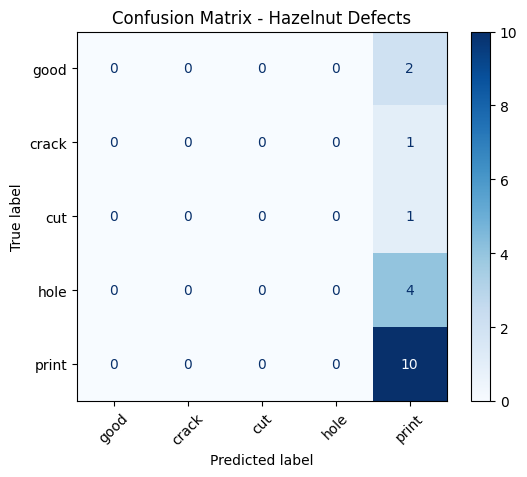


Classification Report (zero_division=0):
              precision    recall  f1-score   support

        good       0.00      0.00      0.00         1
       crack       0.00      0.00      0.00         1
         cut       0.00      0.00      0.00         2
        hole       0.00      0.00      0.00         4
       print       0.56      1.00      0.71        10

    accuracy                           0.56        18
   macro avg       0.11      0.20      0.14        18
weighted avg       0.31      0.56      0.40        18




In [27]:
#@title TO DO: Print the confusion matrix using the predictions and ground truth labels
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=defect_spec.class_names)

# Plot with all classes (even if some have zero predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=defect_spec.class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Hazelnut Defects")
plt.xticks(rotation=45)
plt.show()

# Print classification report with zero_division handled
print("\nClassification Report (zero_division=0):")
print(classification_report(
    y_true, y_pred,
    target_names=defect_spec.class_names,
    zero_division=0
))

# Check for unpredicted classes
unique_pred = np.unique(y_pred)
missing = set(defect_spec.class_names) - set(unique_pred)
if missing:
    print(f"\nWarning: No predictions for classes: {missing}")

## Observations (TO DO)

What did you observe? Will a different classification spec improve things? If yes, then try it out below.

# My Observations

- Only "print" defects are being predicted (56% precision, 100% recall)

- All other classes have 0 predictions - the model can't distinguish them

- The model is biased towards "print" - likely because the prompt is too generic or maybe due to data imbalance

#Other approches i am taking for the imporving the model accuracy

-  Trying with different prompts

## [Optional/Bonus] Rerun 1: With a different spec

In [33]:

from pathlib import Path
from spec import DefectClassificationSpec
from clip_ac import classify_defects
from sklearn.metrics import accuracy_score




defect_spec = DefectClassificationSpec(
    class_names=["good", "crack", "cut", "hole", "print"],
    prompts=["flawless hazelnut, pristine condition, no damage, perfect shell",
        "cracked hazelnut shell, fracture lines, broken pieces, structural damage",
        "cut hazelnut, straight incision, sharp edge damage, sliced surface",
        "hazelnut with holes, circular openings, bore damage, worm infestation",
        "hazelnut with printed text, artificial ink, labeled surface, marked shell"

    ],
    model_name="ViT-B/32"
)


test_dir = Path("data")
y_true, y_pred = classify_defects(defect_spec, test_dir)


# Print some results for verification
print("Predictions")
for true, pred in zip(y_true[:], y_pred[:]):
    print(f"True: {true}, Predicted: {pred}")

accuracy = accuracy_score(y_true, y_pred)
print(f"\nOverall accuracy: {accuracy:.2f}")

Predictions
True: good, Predicted: good
True: print, Predicted: good
True: crack, Predicted: crack
True: good, Predicted: print
True: hole, Predicted: hole
True: cut, Predicted: good
True: hole, Predicted: hole
True: print, Predicted: print
True: hole, Predicted: hole
True: print, Predicted: print
True: print, Predicted: print
True: hole, Predicted: hole
True: print, Predicted: print
True: print, Predicted: good
True: print, Predicted: hole
True: print, Predicted: hole
True: print, Predicted: print
True: print, Predicted: crack

Overall accuracy: 0.61


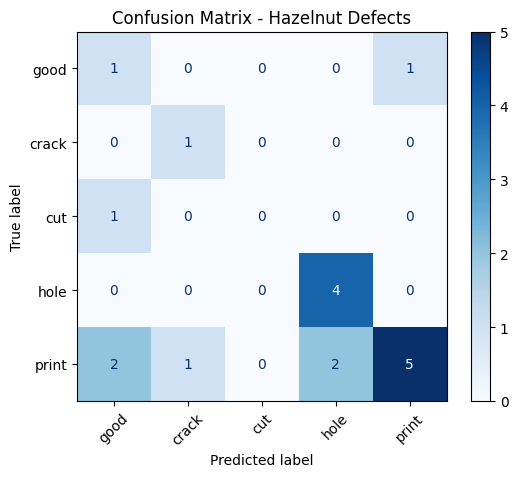


Classification Report (zero_division=0):
              precision    recall  f1-score   support

        good       0.50      1.00      0.67         1
       crack       0.00      0.00      0.00         1
         cut       0.25      0.50      0.33         2
        hole       0.67      1.00      0.80         4
       print       0.83      0.50      0.62        10

    accuracy                           0.61        18
   macro avg       0.45      0.60      0.48        18
weighted avg       0.67      0.61      0.60        18




In [31]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=defect_spec.class_names)

# Plot with all classes (even if some have zero predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=defect_spec.class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Hazelnut Defects")
plt.xticks(rotation=45)
plt.show()

# Print classification report with zero_division handled
print("\nClassification Report (zero_division=0):")
print(classification_report(
    y_true, y_pred,
    target_names=defect_spec.class_names,
    zero_division=0
))

# Check for unpredicted classes
unique_pred = np.unique(y_pred)
missing = set(defect_spec.class_names) - set(unique_pred)
if missing:
    print(f"\nWarning: No predictions for classes: {missing}")

# A little improve in accuracy of 0.05 ,from 0.56 to 0.61.


# Bring code into the main branch

In [34]:
#@title TO DO: Commit the changes to the python files to the current feature branch
!git add spec.py clip_ac.py
!git commit -m "Completed spec and classification function, added improved prompts"

[feature/template-code f449dda] Completed spec and classification function, added improved prompts
 2 files changed, 49 insertions(+), 11 deletions(-)


In [35]:
#@title TO DO: Switch to the main branch, and merge the feature branch into the main branch
!git checkout main
!git merge feature/template-code

Switched to branch 'main'
Your branch is up to date with 'origin/main'.
Updating d6c1daf..f449dda
Fast-forward
 README.md        | 34 +++++++++++++++++++--------
 clip_ac.py       | 70 +++++++++++++++++++++++++++++++++++++++++++++++++++++---
 data/.gitkeep    |  0
 requirements.txt |  6 +++++
 spec.py          | 19 +++++++++++++--
 5 files changed, 115 insertions(+), 14 deletions(-)
 create mode 100644 data/.gitkeep


In [36]:
#@title TO DO: Verify git log to see the latest commit
!git log --oneline -n 5

f449dda (HEAD -> main, feature/template-code) Completed spec and classification function, added improved prompts
c9d8665 (origin/feature/template-code) Update README.md to fix 'References'
3a22633 Template code for the assignment.
d6c1daf (origin/main, origin/HEAD) Basic project structure.


In [37]:
#@title TO DO: Display the changes in the `spec.py` file in the main branch
!git show main:spec.py

"""
Spec containing the configuration for the defect classification task
"""
from pydantic import BaseModel
from typing import List


class DefectClassificationSpec(BaseModel):
    """
    Configuration for defect classification.

    Attributes:
        class_names: List[str]; The list of class names (normal, defect categories).
        prompts: List[str]; The list of prompts corresponding to the class names.
        model_name (str): Name of the CLIP model variant to use.
    """
    class_names: List[str] = []
    prompts: List[str] = []
    model_name: str


# Submission

* Verify that this Colab notebook is owned by you, and in your Google Drive.
* Change the 'Share' settings to 'Anyone with the link' - give read access only.
* Copy the link to the notebook through the 'Share' settings.
* Open a new anonymous browser window, where you are not signed in. Verify that the link you copied opens the notebook, and that all outputs are visible.
* Submit this link through the internship application form.

In [ ]:
!git checkout feature/template-code